# Exploratory Data Analysis — APTOS 2019 Blindness Detection

This notebook explores the raw APTOS dataset before feature extraction.

### Goals
1. Understand the dataset structure and class distribution
2. Visualize sample images per class
3. Analyse image properties (size, brightness, contrast)
4. Identify any data quality issues
5. Confirm preprocessing decisions for the feature extraction pipeline

### Diabetic Retinopathy Severity Scale
| Label | Severity |
|-------|----------|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

## 1. Imports & Configuration

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm

# ── Paths (relative to notebook location) ──────────────────────────────────
ROOT        = Path('..').resolve()
DATA_RAW    = ROOT / 'data' / 'raw'
TRAIN_IMG   = DATA_RAW / 'train_images'
VAL_IMG     = DATA_RAW / 'val_images'
FIGURES_DIR = ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_RAW / 'train_1.csv'
VALID_CSV = DATA_RAW / 'valid.csv'

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_palette('husl')

CLASS_NAMES = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR'
}
CLASS_COLORS = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']

print('✅ Imports OK')
print(f'   ROOT       : {ROOT}')
print(f'   Train images: {TRAIN_IMG}')
print(f'   Val images  : {VAL_IMG}')

✅ Imports OK
   ROOT       : D:\diabetic-retinopathy-feature-selection
   Train images: D:\diabetic-retinopathy-feature-selection\data\raw\train_images
   Val images  : D:\diabetic-retinopathy-feature-selection\data\raw\val_images


## 2. Load CSV Labels

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

# Standardise column names (some versions use 'id_code', others 'image_id')
for df in [train_df, valid_df]:
    if 'id_code' not in df.columns and 'image_id' in df.columns:
        df.rename(columns={'image_id': 'id_code'}, inplace=True)

# Add full image path
train_df['path'] = train_df['id_code'].apply(lambda x: TRAIN_IMG / f'{x}.png')
valid_df['path'] = valid_df['id_code'].apply(lambda x: VAL_IMG / f'{x}.png')

# Add class name
train_df['class_name'] = train_df['diagnosis'].map(CLASS_NAMES)
valid_df['class_name'] = valid_df['diagnosis'].map(CLASS_NAMES)

print(f'Train samples : {len(train_df):,}')
print(f'Val samples   : {len(valid_df):,}')
print(f'Total         : {len(train_df)+len(valid_df):,}')
print()
print('Train CSV head:')
train_df.head()

Train samples : 2,930
Val samples   : 366
Total         : 3,296

Train CSV head:


,id_code,diagnosis,path,class_name
0,1ae8c165fd53,2,D:\diabetic-retinopathy-feature-selection\data...,Moderate
1,1b329a127307,1,D:\diabetic-retinopathy-feature-selection\data...,Mild
2,1b32e1d775ea,4,D:\diabetic-retinopathy-feature-selection\data...,Proliferative DR
3,1b3647865779,0,D:\diabetic-retinopathy-feature-selection\data...,No DR
4,1b398c0494d1,0,D:\diabetic-retinopathy-feature-selection\data...,No DR


In [3]:
# Verify files actually exist on disk
train_missing = train_df[~train_df['path'].apply(lambda p: p.exists())]
val_missing   = valid_df[~valid_df['path'].apply(lambda p: p.exists())]

print(f'Missing train images : {len(train_missing)}')
print(f'Missing val images   : {len(val_missing)}')

# Drop missing (if any)
train_df = train_df[train_df['path'].apply(lambda p: p.exists())].reset_index(drop=True)
valid_df = valid_df[valid_df['path'].apply(lambda p: p.exists())].reset_index(drop=True)
print(f'\nUsable train: {len(train_df)} | Usable val: {len(valid_df)}')

Missing train images : 0
Missing val images   : 0

Usable train: 2930 | Usable val: 366


## 3. Class Distribution

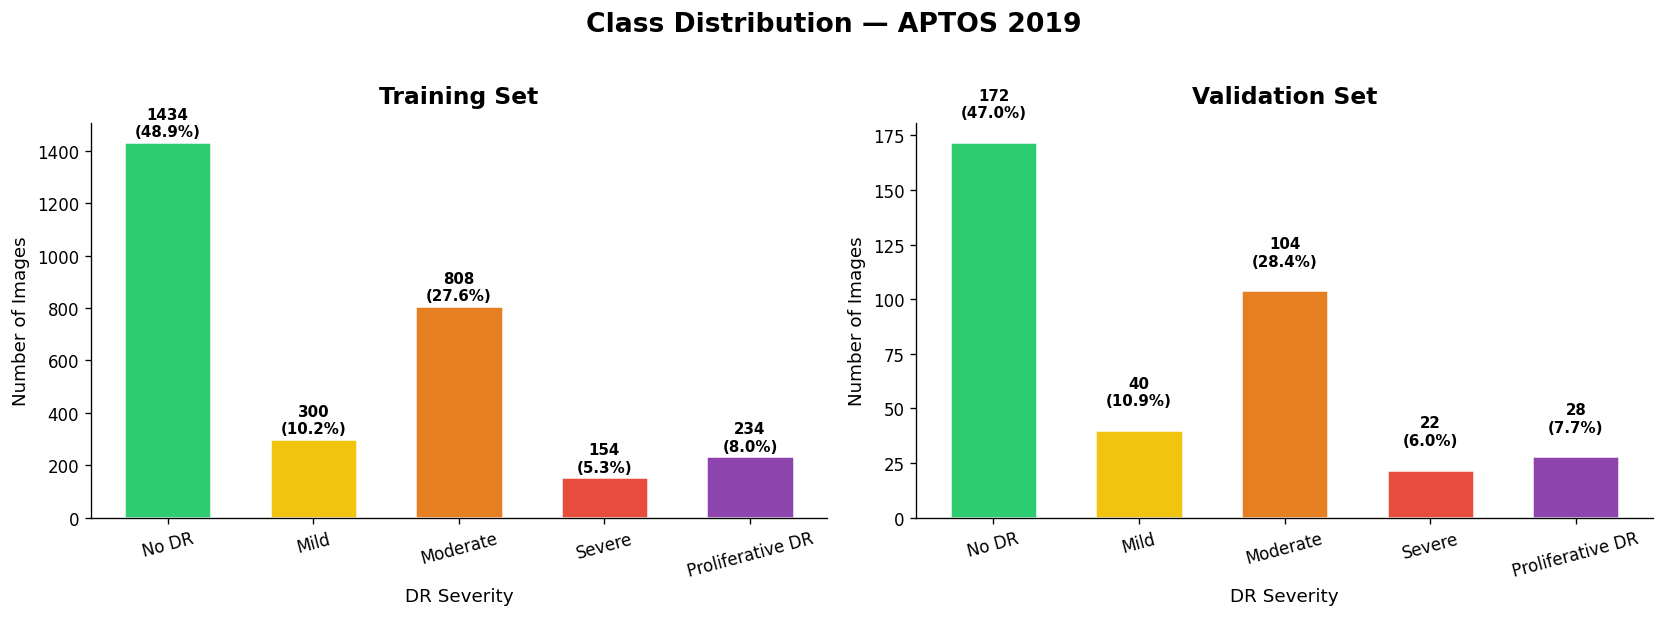

💾 Saved → results/figures/class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [(train_df, 'Training Set'), (valid_df, 'Validation Set')]):
    counts = df['diagnosis'].value_counts().sort_index()
    bars = ax.bar(
        [CLASS_NAMES[i] for i in counts.index],
        counts.values,
        color=CLASS_COLORS,
        edgecolor='white',
        linewidth=1.5,
        width=0.6
    )
    # Add count labels on bars
    for bar, count in zip(bars, counts.values):
        pct = count / counts.sum() * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('DR Severity', fontsize=11)
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Class Distribution — APTOS 2019', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()
print('💾 Saved → results/figures/class_distribution.png')

In [5]:
# Imbalance ratio (important for GA fitness function)
counts = train_df['diagnosis'].value_counts().sort_index()
majority = counts.max()
print('⚠️  Class imbalance analysis (training set):')
print('-' * 45)
for cls, cnt in counts.items():
    ratio = majority / cnt
    bar = '█' * int(cnt / 50)
    print(f'  Class {cls} ({CLASS_NAMES[cls]:<18}): {cnt:4d}  ratio={ratio:.1f}x  {bar}')
print()
print('→ Class 0 (No DR) dominates — use stratified splits in the GA classifier.')

⚠️  Class imbalance analysis (training set):
---------------------------------------------
  Class 0 (No DR             ): 1434  ratio=1.0x  ████████████████████████████
  Class 1 (Mild              ):  300  ratio=4.8x  ██████
  Class 2 (Moderate          ):  808  ratio=1.8x  ████████████████
  Class 3 (Severe            ):  154  ratio=9.3x  ███
  Class 4 (Proliferative DR  ):  234  ratio=6.1x  ████

→ Class 0 (No DR) dominates — use stratified splits in the GA classifier.


## solve the imbalance problem by makeing the data only two classes ,DR and NO DR

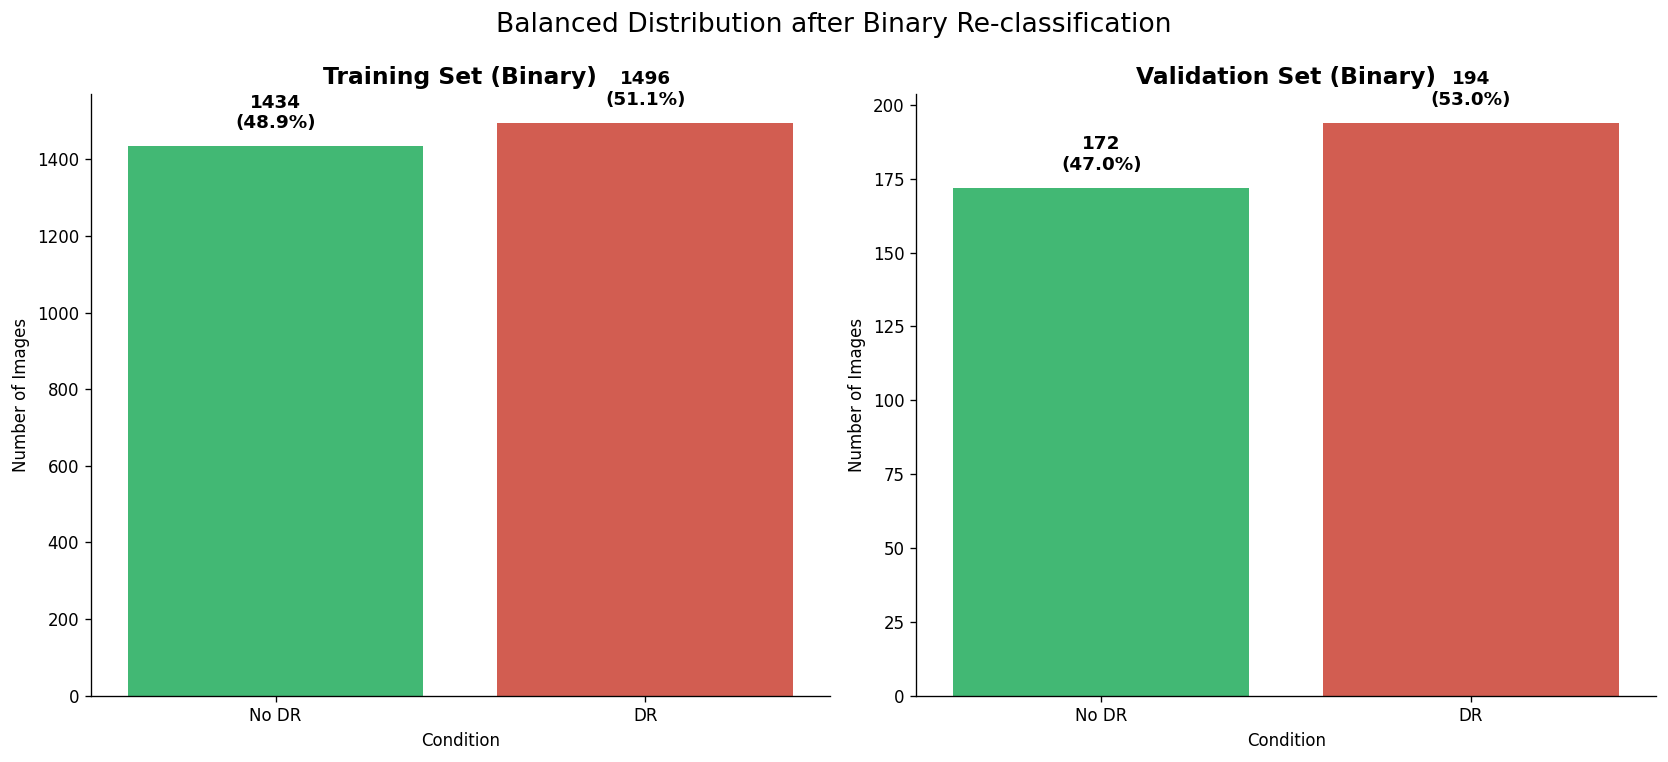

Final Training Balance: 
binary_name
DR       51.05802
No DR    48.94198
Name: proportion, dtype: float64


In [6]:
# ── Binarizing the Dataset ──────────────────────────────────────────────────

# Create a mapping for the new binary classes
BINARY_NAMES = {0: 'No DR', 1: 'DR'}
BINARY_COLORS = ['#2ecc71', '#e74c3c'] # Green for Healthy, Red for DR

# 1. Apply binarization: 0 stays 0, (1, 2, 3, 4) all become 1
train_df['binary_diagnosis'] = (train_df['diagnosis'] > 0).astype(int)
valid_df['binary_diagnosis'] = (valid_df['diagnosis'] > 0).astype(int)

# 2. Map the names for visualization
train_df['binary_name'] = train_df['binary_diagnosis'].map(BINARY_NAMES)
valid_df['binary_name'] = valid_df['binary_diagnosis'].map(BINARY_NAMES)

# 3. Visualize the new balanced distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

for i, (df, title) in enumerate([(train_df, 'Training Set (Binary)'), 
                                 (valid_df, 'Validation Set (Binary)')]):
    sns.countplot(data=df, x='binary_name', palette=BINARY_COLORS, ax=ax[i], order=['No DR', 'DR'])
    ax[i].set_title(title, fontweight='bold', fontsize=14)
    ax[i].set_xlabel('Condition')
    ax[i].set_ylabel('Number of Images')
    
    # Add percentage labels on top of bars
    total = len(df)
    for p in ax[i].patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax[i].annotate(f'{int(p.get_height())}\n({percentage})', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 20), 
                       textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.suptitle('Balanced Distribution after Binary Re-classification', fontsize=16, y=1.05)
plt.show()

# Print the final counts
print(f"Final Training Balance: \n{train_df['binary_name'].value_counts(normalize=True) * 100}")

In [16]:
train_df

,id_code,diagnosis,path,class_name,binary_diagnosis,binary_name
0,1ae8c165fd53,2,D:\diabetic-retinopathy-feature-selection\data...,Moderate,1,DR
1,1b329a127307,1,D:\diabetic-retinopathy-feature-selection\data...,Mild,1,DR
2,1b32e1d775ea,4,D:\diabetic-retinopathy-feature-selection\data...,Proliferative DR,1,DR
3,1b3647865779,0,D:\diabetic-retinopathy-feature-selection\data...,No DR,0,No DR
4,1b398c0494d1,0,D:\diabetic-retinopathy-feature-selection\data...,No DR,0,No DR
...,...,...,...,...,...,...
2925,e4a44f9158dc,0,D:\diabetic-retinopathy-feature-selection\data...,No DR,0,No DR
2926,e4ae1ee6aada,0,D:\diabetic-retinopathy-feature-selection\data...,No DR,0,No DR
2927,e4b0df29b96f,0,D:\diabetic-retinopathy-feature-selection\data...,No DR,0,No DR
2928,e4c799738a19,0,D:\diabetic-retinopathy-feature-selection\data...,No DR,0,No DR


## 4. Sample Images Per Class

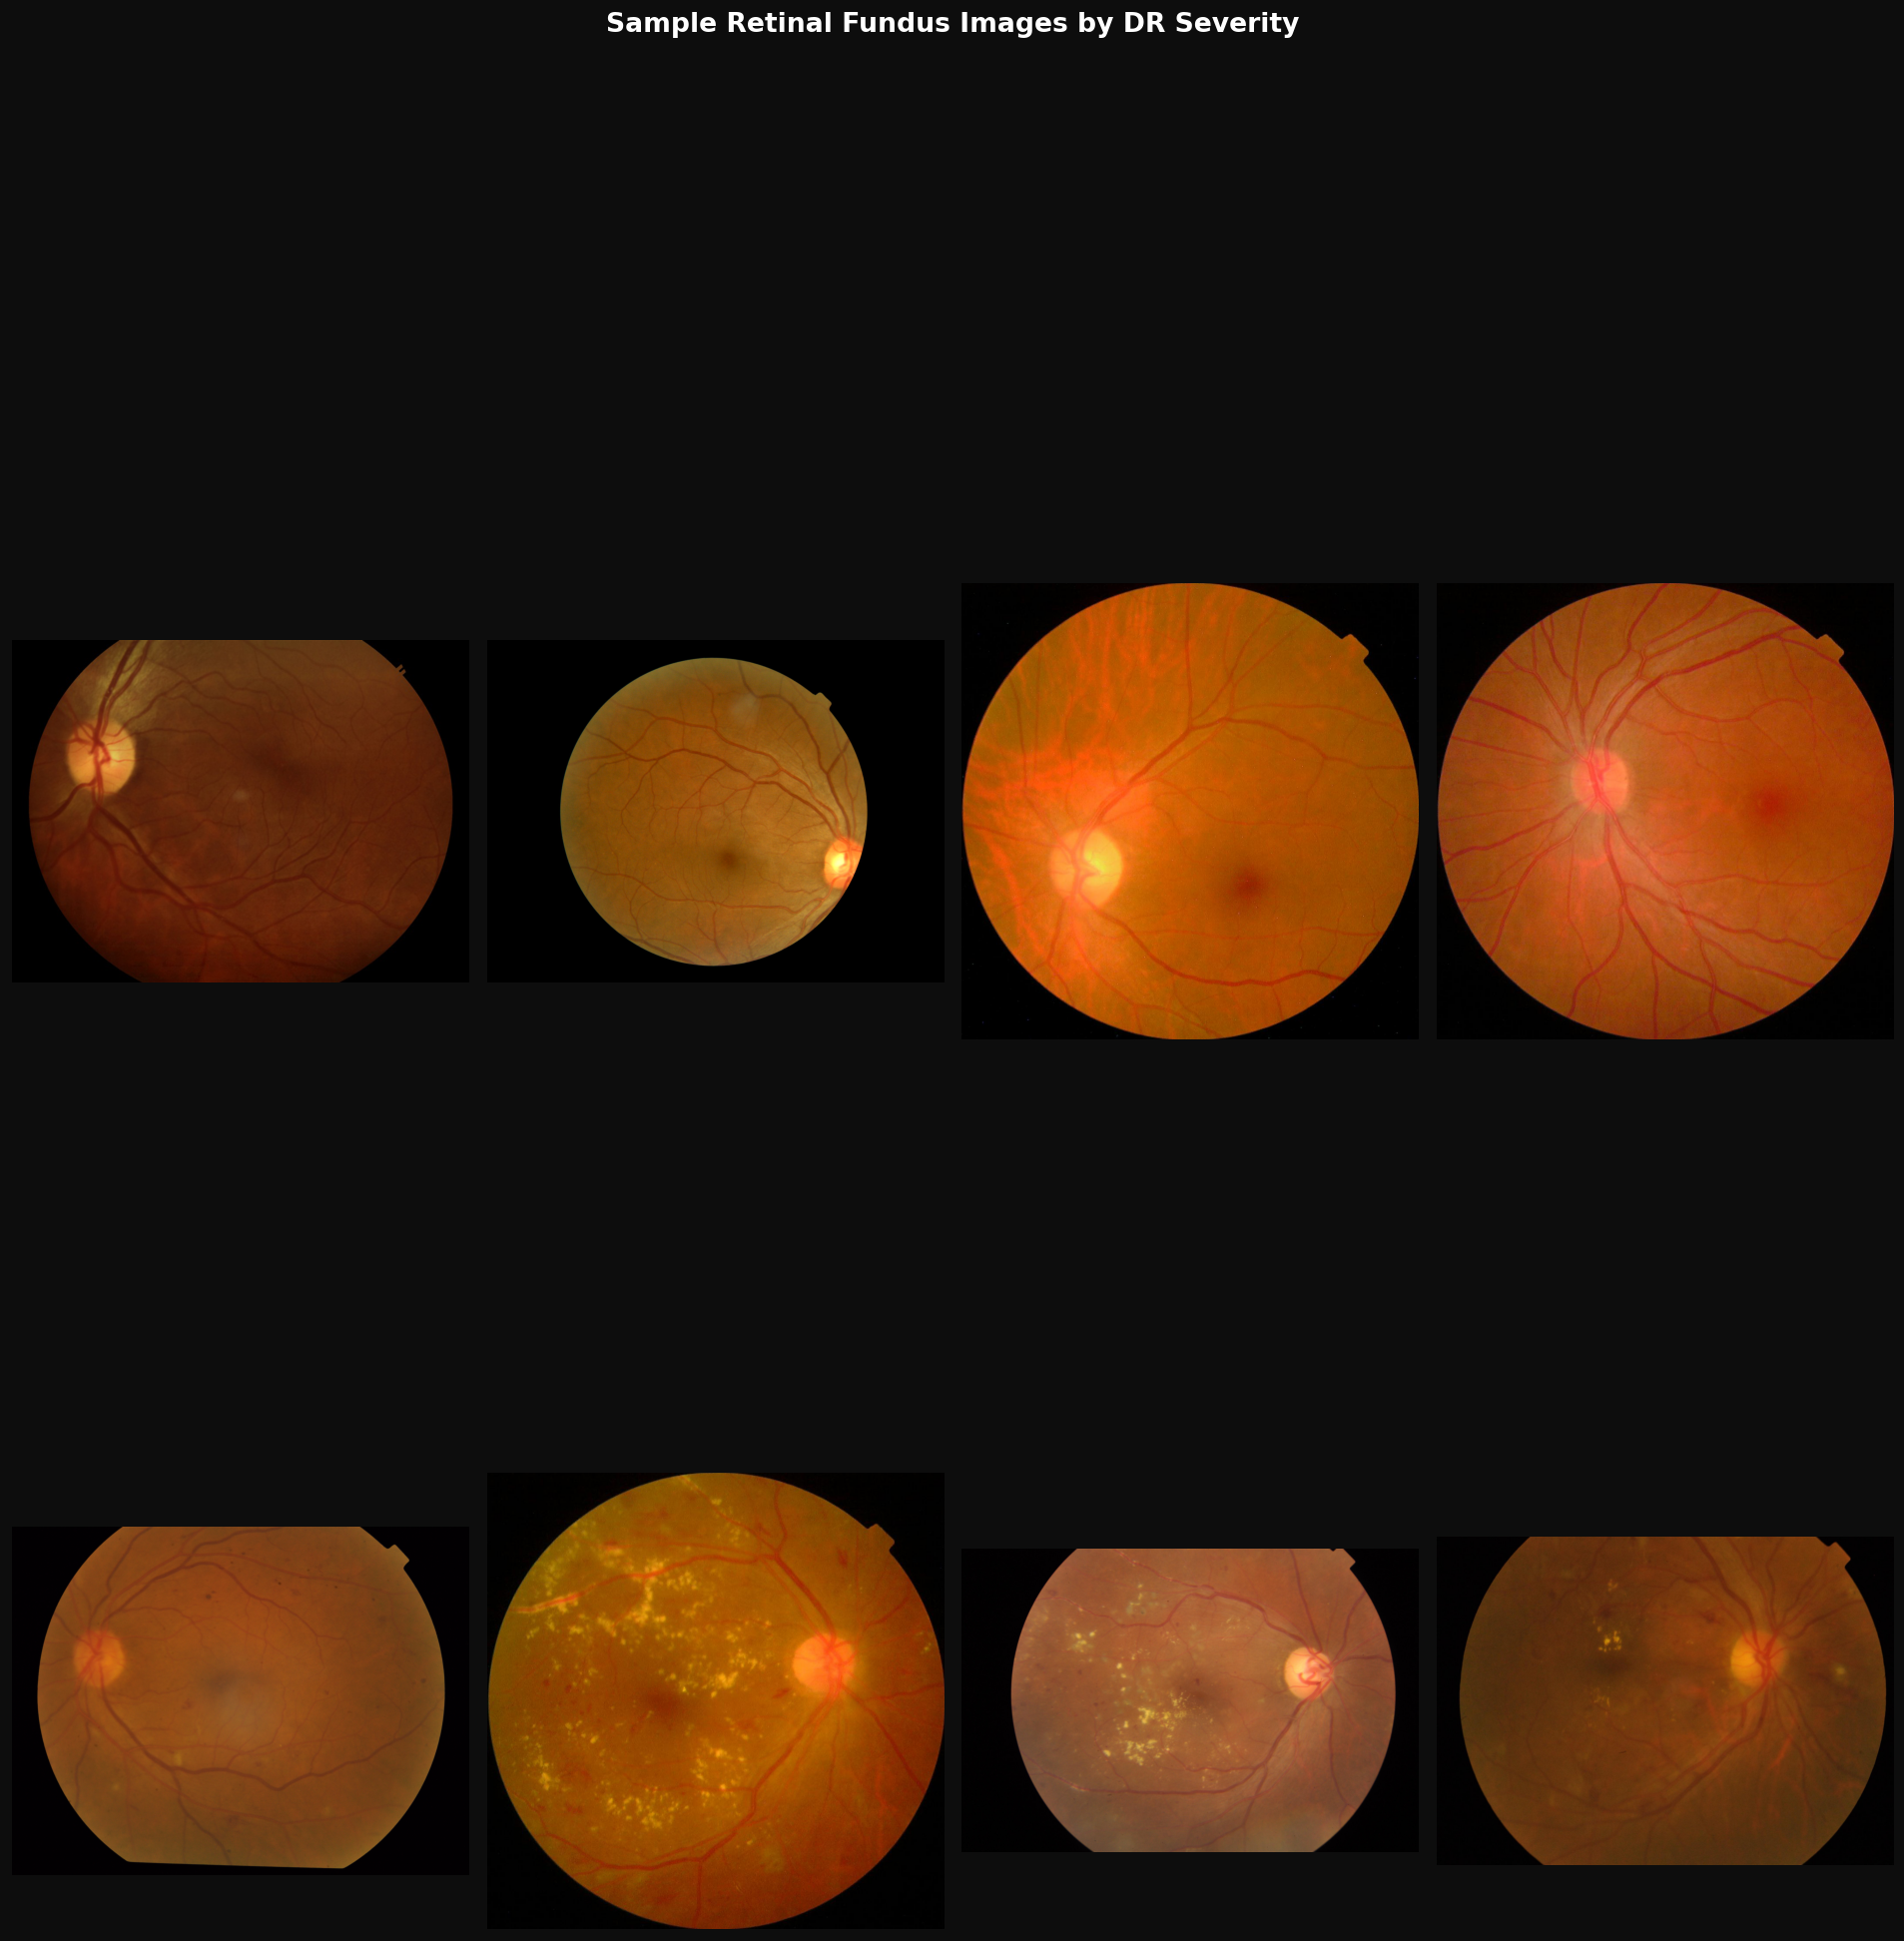

💾 Saved → results/figures/sample_images_per_class.png


In [21]:
N_SAMPLES = 4  # images per class
N_CLASSES = 2

fig, axes = plt.subplots(N_CLASSES, N_SAMPLES, figsize=(16, 20))
fig.patch.set_facecolor('#0d0d0d')

for cls_idx in range(N_CLASSES):
    cls_samples = train_df[train_df['binary_diagnosis'] == cls_idx].sample(
        min(N_SAMPLES, len(train_df[train_df['binary_diagnosis'] == cls_idx])),
        random_state=42
    )
    for col, (_, row) in enumerate(cls_samples.iterrows()):
        ax = axes[cls_idx][col]
        try:
            img = Image.open(row['path']).convert('RGB')
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, 'Error', transform=ax.transAxes, ha='center', color='red')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(
                f"Class {cls_idx}\n{BINARY_NAMES[cls_idx]}",
                fontsize=11, color=CLASS_COLORS[cls_idx],
                fontweight='bold', rotation=0,
                labelpad=60, va='center'
            )

plt.suptitle('Sample Retinal Fundus Images by DR Severity', 
             fontsize=16, color='white', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sample_images_per_class.png', 
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('💾 Saved → results/figures/sample_images_per_class.png')

## 5. Image Properties Analysis

In [18]:
# Sample up to 300 images for fast analysis
SAMPLE_N = min(300, len(train_df))
sample_df = train_df.sample(SAMPLE_N, random_state=42)

records = []
for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_N, desc='Reading image properties'):
    try:
        img = cv2.imread(str(row['path']))
        if img is None:
            continue
        h, w = img.shape[:2]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        records.append({
            'id_code'   : row['id_code'],
            'diagnosis' : row['binary_diagnosis'],
            'width'     : w,
            'height'    : h,
            'aspect'    : round(w / h, 3),
            'brightness': float(gray.mean()),
            'contrast'  : float(gray.std()),
            'filesize_kb': os.path.getsize(str(row['path'])) / 1024
        })
    except Exception:
        pass

props_df = pd.DataFrame(records)
print(f'\nAnalysed {len(props_df)} images')
props_df.describe().round(2)

Reading image properties:   0%|          | 0/300 [00:00<?, ?it/s]


Analysed 300 images


,diagnosis,width,height,aspect,brightness,contrast,filesize_kb
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,0.51,2012.81,1523.57,1.29,66.08,38.32,2330.66
std,0.50,862.66,539.57,0.18,17.19,10.02,1753.15
min,0.00,640.00,480.00,1.00,17.15,12.47,266.22
25%,0.00,1050.00,1050.00,1.29,54.60,30.71,987.58
50%,1.00,2145.00,1636.00,1.33,67.52,39.47,1884.52
75%,1.00,2588.00,1958.00,1.39,79.99,44.93,2743.78
max,1.00,4288.00,2848.00,1.51,107.68,70.73,7305.87


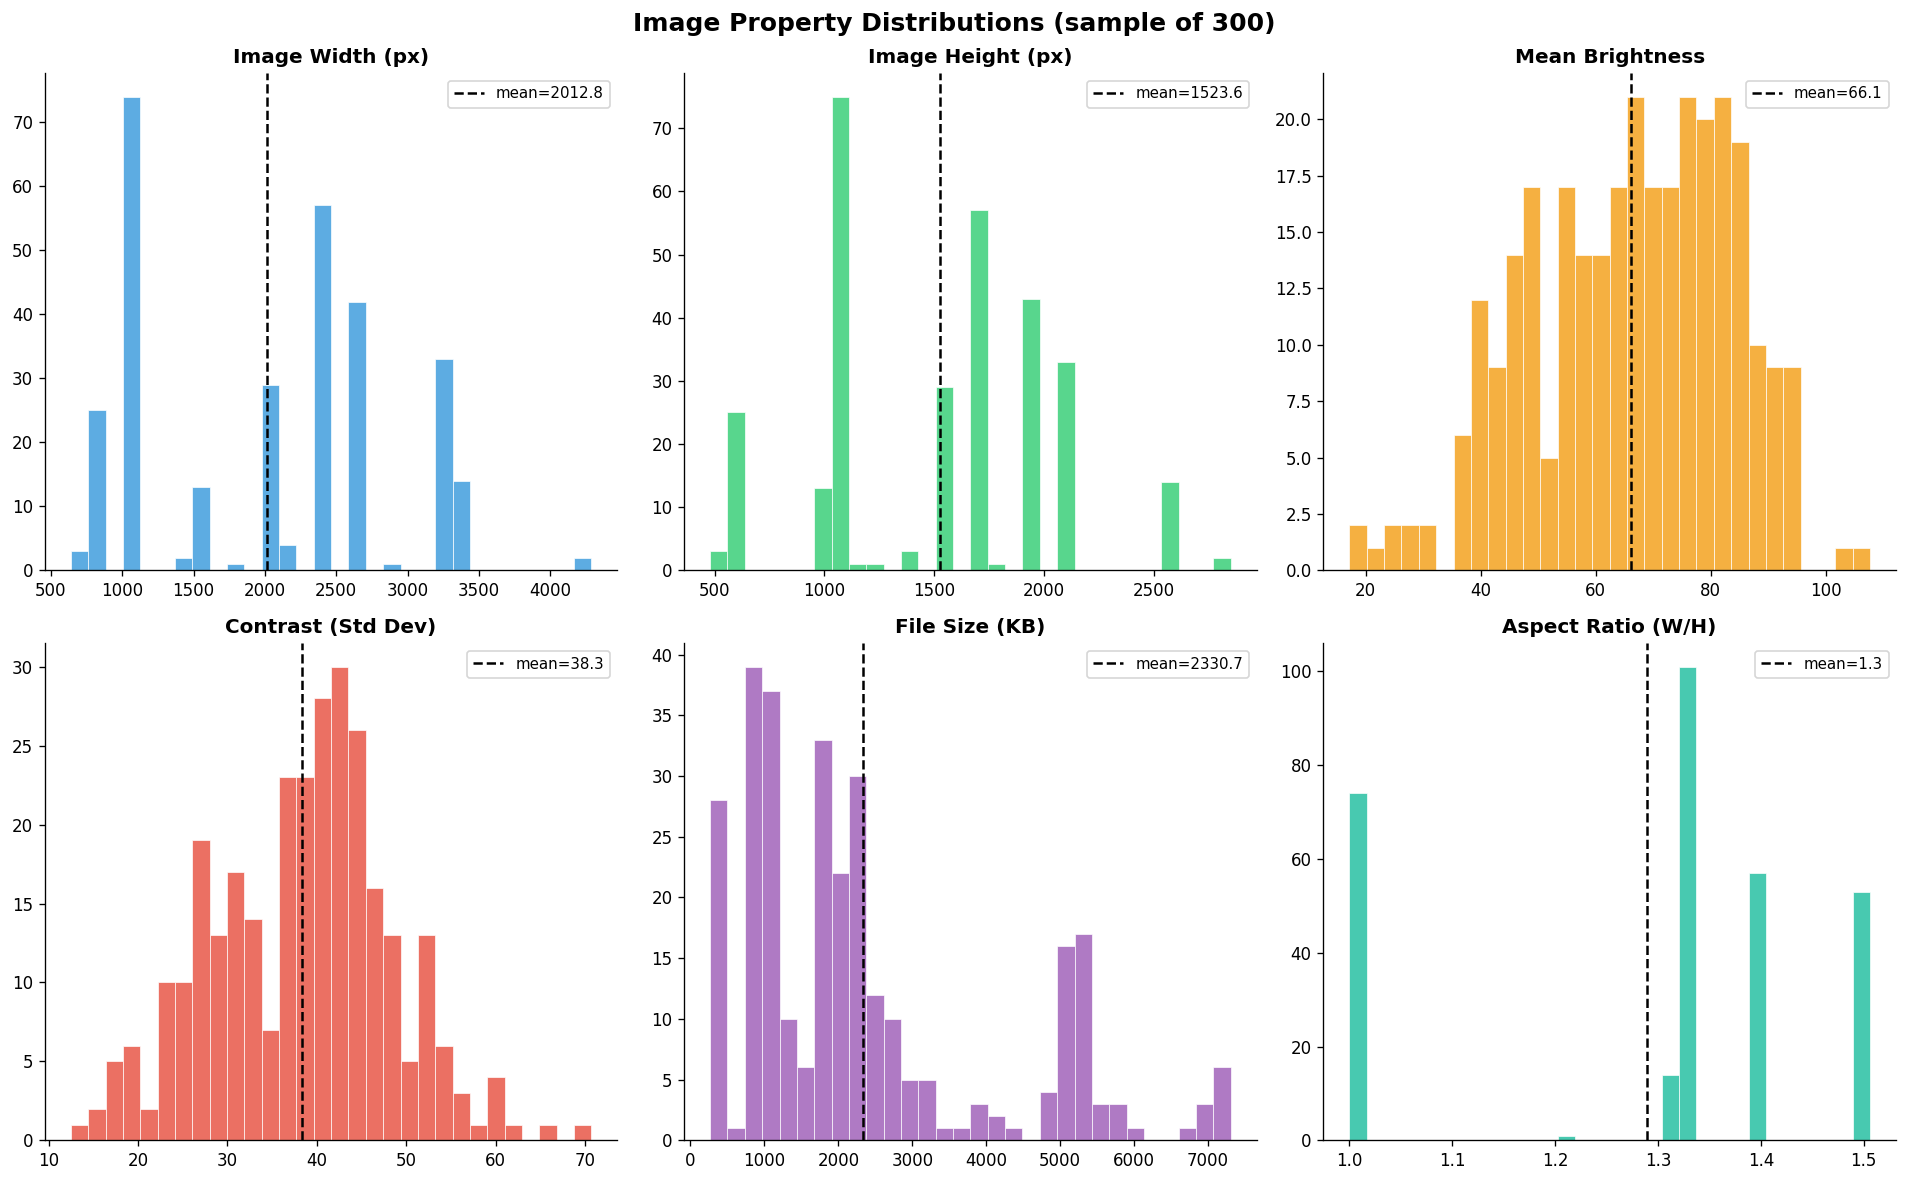

💾 Saved → results/figures/image_properties.png


In [ ]:
# Plot image property distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

props_to_plot = [
    ('width',       'Image Width (px)',        '#3498db'),
    ('height',      'Image Height (px)',       '#2ecc71'),
    ('brightness',  'Mean Brightness',         '#f39c12'),
    ('contrast',    'Contrast (Std Dev)',       '#e74c3c'),
    ('filesize_kb', 'File Size (KB)',           '#9b59b6'),
    ('aspect',      'Aspect Ratio (W/H)',       '#1abc9c'),
]

for ax, (col, label, color) in zip(axes, props_to_plot):
    ax.hist(props_df[col], bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(props_df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'mean={props_df[col].mean():.1f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Image Property Distributions (sample of 300)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'image_properties.png', bbox_inches='tight')
plt.show()
print('💾 Saved → results/figures/image_properties.png')

In [9]:
# Image dimensions — unique sizes
size_counts = props_df.groupby(['width','height']).size().reset_index(name='count').sort_values('count', ascending=False)
print('Top 10 image dimensions found:')
print(size_counts.head(10).to_string(index=False))
print(f'\nUnique sizes: {len(size_counts)}')
print('→ Resizing to 224×224 is required (ResNet50 standard input).')

Top 10 image dimensions found:
 width  height  count
  1050    1050     74
  2416    1736     57
  2588    1958     42
  3216    2136     33
  2048    1536     29
   819     614     25
  3388    2588     14
  1504    1000     13
  2144    1424      3
   640     480      3

Unique sizes: 16
→ Resizing to 224×224 is required (ResNet50 standard input).


## 6. Brightness & Contrast Per Class

In [25]:
# Sync the binary column into the properties dataframe
props_df['binary_diagnosis'] = (props_df['diagnosis'] > 0).astype(int)

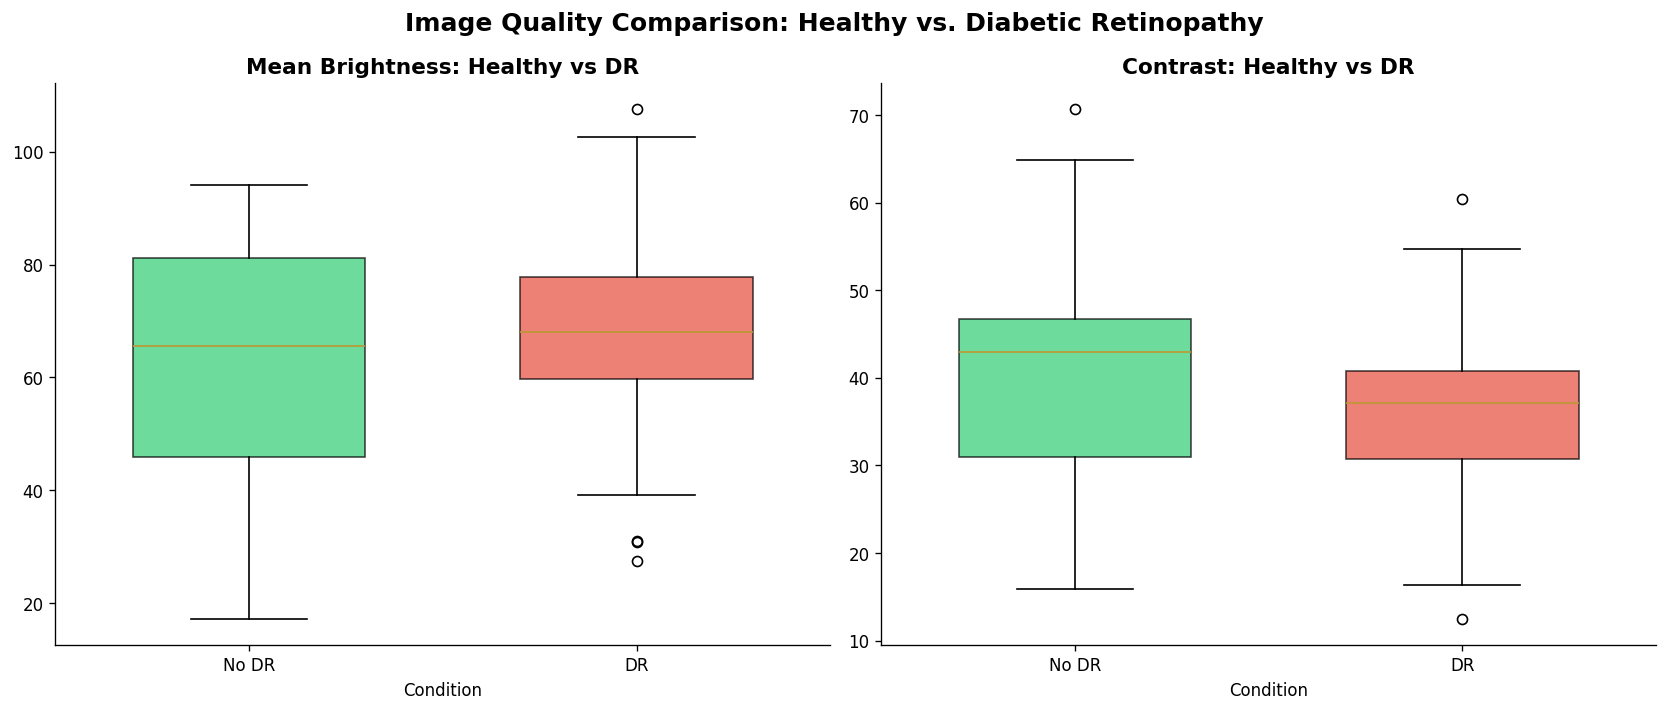

💾 Saved → results/figures/brightness_contrast_binary.png


In [26]:
# 1. Ensure props_df has the binary column
props_df['binary_diagnosis'] = (props_df['diagnosis'] > 0).astype(int)

# 2. Plotting setup
BINARY_NAMES = {0: 'No DR', 1: 'DR'}
BINARY_COLORS = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in zip(
    axes,
    ['brightness', 'contrast'],
    ['Mean Brightness: Healthy vs DR', 'Contrast: Healthy vs DR']
):
    # Group data by the new binary classes
    data_by_class = [
        props_df[props_df['binary_diagnosis'] == cls][metric].dropna().values
        for cls in range(2)
    ]
    
    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        widths=0.6,
        labels=[f'{BINARY_NAMES[i]}' for i in range(2)]
    )
    
    for patch, color in zip(bp['boxes'], BINARY_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Condition')
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('Image Quality Comparison: Healthy vs. Diabetic Retinopathy', fontsize=15, fontweight='bold')
plt.tight_layout()

# Save and show
plt.savefig(FIGURES_DIR / 'brightness_contrast_binary.png', bbox_inches='tight')
plt.show()

print('💾 Saved → results/figures/brightness_contrast_binary.png')

## 7. RGB Channel Analysis

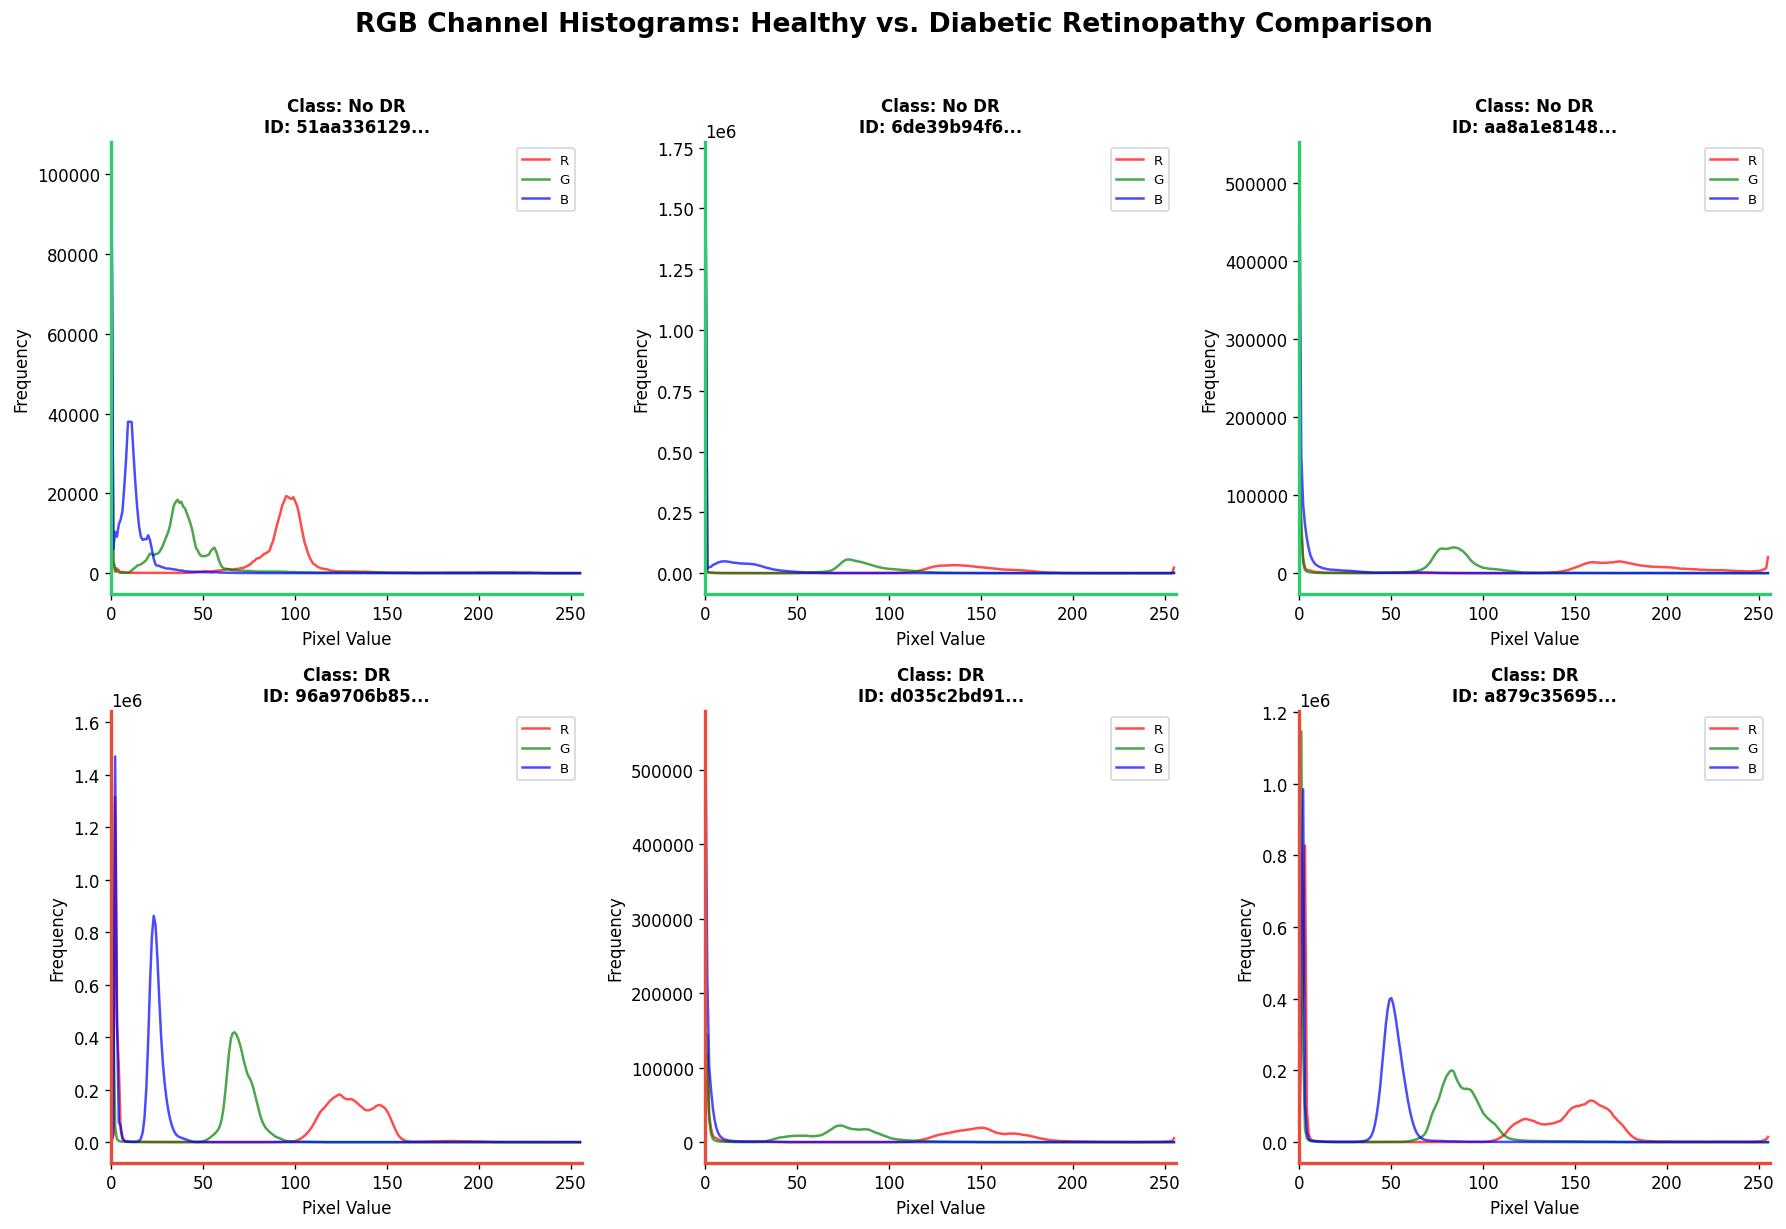

💾 Saved → results/figures/rgb_histograms_binary_comparison.png


In [27]:
# ── RGB Histograms for Healthy vs. DR Comparison ────────────────────────────

# 1. Select 3 samples from each binary class
no_dr_samples = train_df[train_df['binary_diagnosis'] == 0].sample(3, random_state=42)
dr_samples    = train_df[train_df['binary_diagnosis'] == 1].sample(3, random_state=42)

# Combine them (3 Healthy first, then 3 DR)
sample_df = pd.concat([no_dr_samples, dr_samples])
sample_paths = sample_df['path'].tolist()
sample_labels = sample_df['binary_name'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
channel_colors = ['red', 'green', 'blue']

for i, (ax, path, label) in enumerate(zip(axes, sample_paths, sample_labels)):
    # Read and convert image
    img = cv2.imread(str(path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Calculate and plot histograms for each channel
    for ch, (color, ch_name) in enumerate(zip(channel_colors, ['R','G','B'])):
        hist = cv2.calcHist([img_rgb], [ch], None, [256], [0, 256])
        ax.plot(hist, color=color, alpha=0.7, linewidth=1.5, label=ch_name)
    
    ax.set_xlim([0, 256])
    # Title showing Class and a snippet of the ID
    ax.set_title(f"Class: {label}\nID: {Path(path).stem[:10]}...", fontsize=10, fontweight='bold')
    ax.set_xlabel('Pixel Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    
    # Add a border color to distinguish the groups (Green for Healthy, Red for DR)
    border_color = '#2ecc71' if label == 'No DR' else '#e74c3c'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2)

plt.suptitle('RGB Channel Histograms: Healthy vs. Diabetic Retinopathy Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the updated comparison
plt.savefig(FIGURES_DIR / 'rgb_histograms_binary_comparison.png', bbox_inches='tight')
plt.show()

print('💾 Saved → results/figures/rgb_histograms_binary_comparison.png')

## 8. Image Preprocessing Preview
Visualise what each image looks like after the preprocessing pipeline (resize → normalize) that will be used for feature extraction.

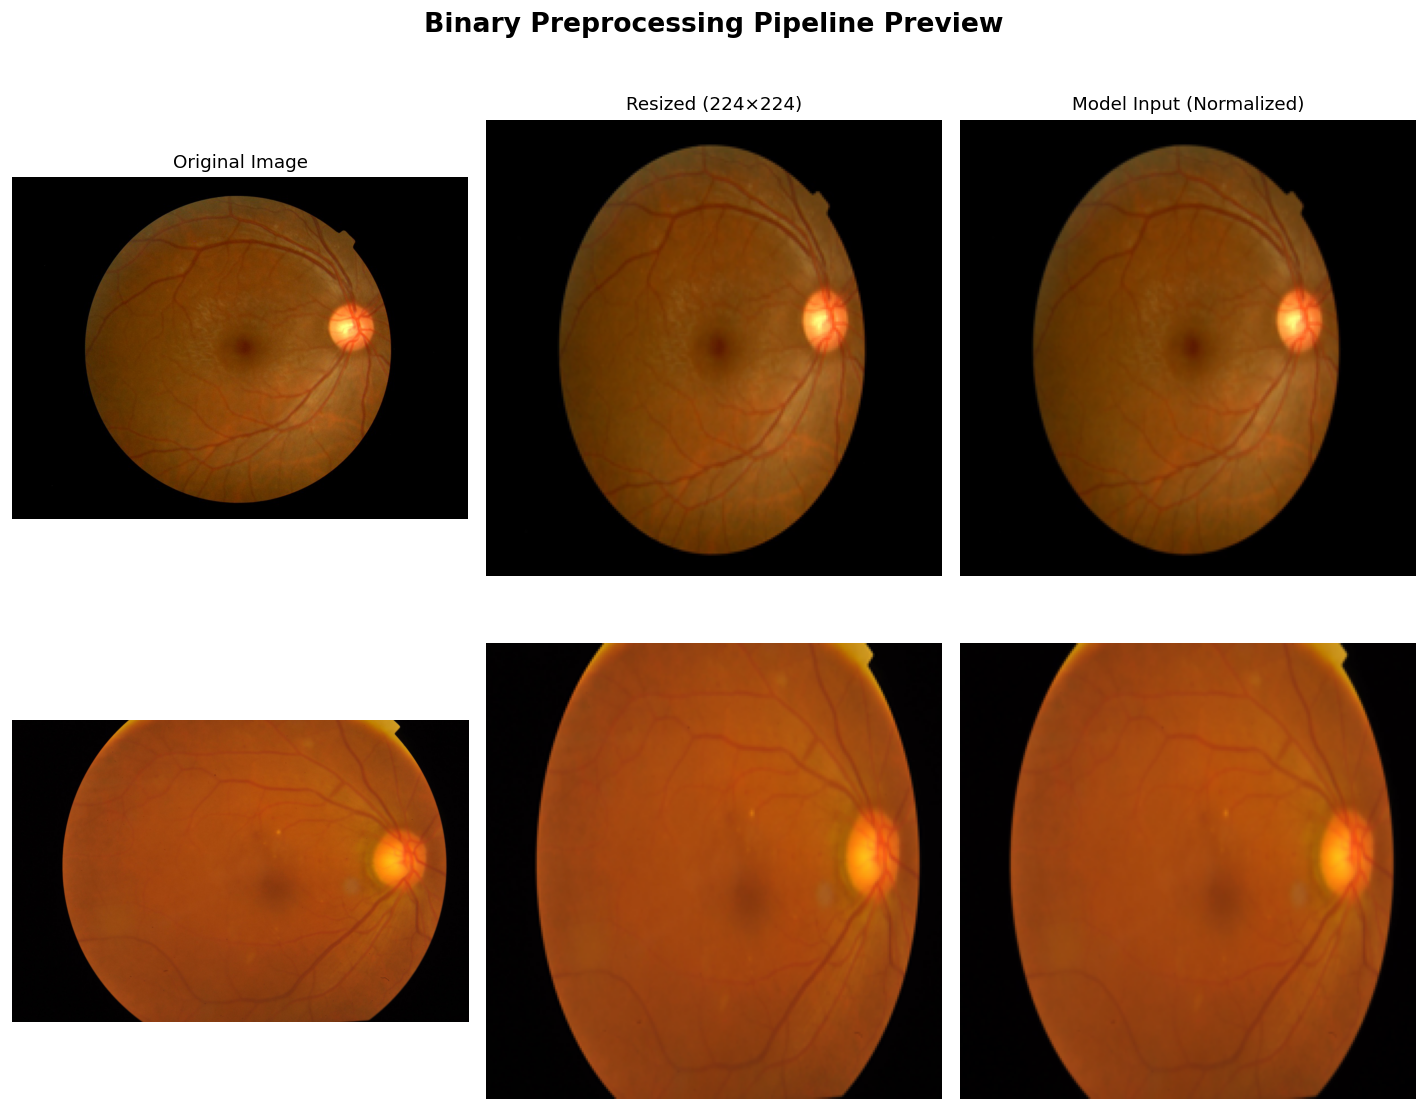

💾 Saved → results/figures/preprocessing_preview_binary.png


In [28]:
# ── Preprocessing Preview: Healthy vs. DR ──────────────────────────────────

# 1. Update the grid for 2 classes (rows) and 3 stages (columns)
fig, axes = plt.subplots(2, 3, figsize=(12, 10))

for cls in range(2):
    # Select the first sample for the current binary class
    row_data = train_df[train_df['binary_diagnosis'] == cls].iloc[0]
    raw_img  = Image.open(row_data['path']).convert('RGB')
    
    # Apply the same transforms used in our feature extractor
    tensor   = transform(raw_img)
    proc_img = denormalize(tensor)

    # Column 0: Raw Image
    axes[cls][0].imshow(raw_img)
    axes[cls][0].set_title('Original Image' if cls == 0 else '', fontsize=11)
    axes[cls][0].set_ylabel(f"{BINARY_NAMES[cls]}", 
                            fontsize=12, fontweight='bold', 
                            color=BINARY_COLORS[cls],
                            rotation=0, labelpad=50, va='center')
    axes[cls][0].axis('off')

    # Column 1: Resized to model input size
    resized = raw_img.resize((224, 224))
    axes[cls][1].imshow(resized)
    axes[cls][1].set_title('Resized (224×224)' if cls == 0 else '', fontsize=11)
    axes[cls][1].axis('off')

    # Column 2: Normalized (ImageNet distribution)
    axes[cls][2].imshow(proc_img)
    axes[cls][2].set_title('Model Input (Normalized)' if cls == 0 else '', fontsize=11)
    axes[cls][2].axis('off')

plt.suptitle('Binary Preprocessing Pipeline Preview', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the updated binary preview
plt.savefig(FIGURES_DIR / 'preprocessing_preview_binary.png', bbox_inches='tight')
plt.show()

print('💾 Saved → results/figures/preprocessing_preview_binary.png')

## 9. Dataset Summary

In [29]:
print('=' * 55)
print('   APTOS 2019 — Binary EDA Summary')
print('=' * 55)

total_images = len(train_df) + len(valid_df)
print(f'   Total usable images      : {total_images:,}')
print(f'   Training images          : {len(train_df):,}')
print(f'   Validation images        : {len(valid_df):,}')
print()

print('   Binary Class Breakdown (Train):')
for cls in range(2):
    n = len(train_df[train_df['binary_diagnosis'] == cls])
    pct = n / len(train_df) * 100
    name = BINARY_NAMES[cls]
    print(f'     {name:<22}: {n:4d}  ({pct:.1f}%)')

print()
print('   Image Properties (Dataset-wide):')
# Assuming size_counts and props_df are defined in your previous cells
print(f'     Unique sizes found      : {len(size_counts)}')
print(f'     Avg brightness          : {props_df["brightness"].mean():.1f}')
print(f'     Avg contrast (std)      : {props_df["contrast"].mean():.1f}')

print()
print('   Updated Pipeline Decisions:')
print('     Task Type               : Binary Classification (No DR vs DR)')
print('     Input Resolution        : 224×224 (Fixed for ResNet50)')
print('     Normalisation           : ImageNet Mean/Std')
print('     Class Balance           : Balanced (~50/50 Split)')
print('     Class Weighting         : Not required (Balanced Binary)')
print('     Feature Target          : 2,048 Deep Features (Pre-GA)')
print('=' * 55)

   APTOS 2019 — Binary EDA Summary
   Total usable images      : 3,296
   Training images          : 2,930
   Validation images        : 366

   Binary Class Breakdown (Train):
     No DR                 : 1434  (48.9%)
     DR                    : 1496  (51.1%)

   Image Properties (Dataset-wide):
     Unique sizes found      : 16
     Avg brightness          : 66.1
     Avg contrast (std)      : 38.3

   Updated Pipeline Decisions:
     Task Type               : Binary Classification (No DR vs DR)
     Input Resolution        : 224×224 (Fixed for ResNet50)
     Normalisation           : ImageNet Mean/Std
     Class Balance           : Balanced (~50/50 Split)
     Class Weighting         : Not required (Balanced Binary)
     Feature Target          : 2,048 Deep Features (Pre-GA)


quick test

In [34]:
import torch
import numpy as np
from src.extraction.dataloader import create_dataloaders
from src.extraction.feature_extractor import ResNetFeatureExtractor

# 1. Setup - Use the ROOT path we defined in EDA to avoid FileNotFoundError
data_path = str(ROOT / "data")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Testing on: {device}")

# 2. Load a tiny sample
# Added num_workers=0 for the test to avoid Windows multiprocessing issues during debugging
loaders = create_dataloaders(data_path, batch_size=4, num_workers=0)
test_loader = loaders['train']

# 3. Initialize Extractor
extractor = ResNetFeatureExtractor()

# 4. Process one batch
images, labels = next(iter(test_loader))

# --- NEW: Binarize labels for the test ---
# This mirrors your EDA decision: 0 is Healthy, >0 is DR
binary_labels = (labels > 0).long() 
# -----------------------------------------

print(f"✅ Input batch shape   : {images.shape}")  # [4, 3, 224, 224]
print(f"✅ Original labels     : {labels.tolist()}")
print(f"✅ Binarized labels    : {binary_labels.tolist()}")

features = extractor(images)
print(f"✅ Output features shape: {features.shape}") # [4, 2048]

# 5. Final Check
if not torch.isnan(features).any():
    print("\n💎 TEST PASSED: GPU is active, paths are correct, and features are clean.")
else:
    print("\n❌ Warning: Found NaN values in features!")

🚀 Testing on: cuda
Using device: cuda
✅ Input batch shape   : torch.Size([4, 3, 224, 224])
✅ Original labels     : [0, 2, 0, 1]
✅ Binarized labels    : [0, 1, 0, 1]


RuntimeError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [24]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available? {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("CUDA is still not available. We might need to restart the notebook kernel.")

PyTorch version: 2.5.1+cu121
Is CUDA available? True
Current GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Total VRAM: 8.55 GB
